# K-Means 聚类算法全过程详细可视化
本 Notebook 旨在详细展示 K-Means 聚类算法的每一步执行过程，包括初始中心的选取、样本的分配、中心的更新轨迹以及最终的收敛状态。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体以支持图表显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

## 1. 准备并可视化原始数据
首先，我们加载作业中提供的 28 个二维数据点，并在坐标系中绘制出来，观察其自然分布形态。

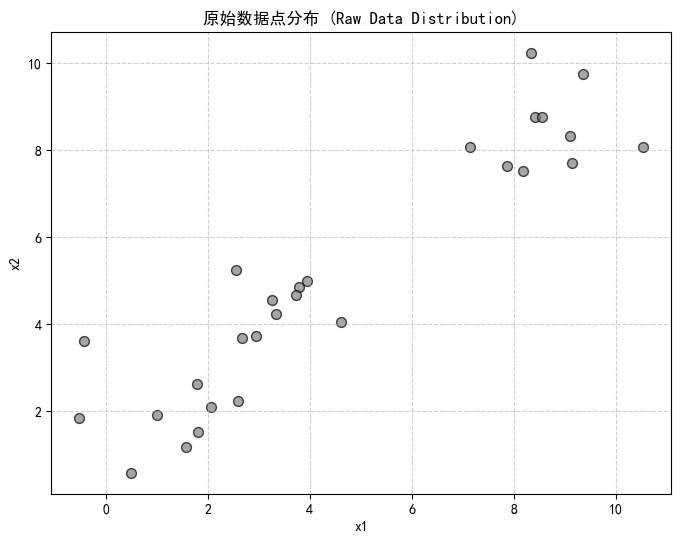

In [2]:
data = np.array([
    [-0.5200, 1.8539], [2.5849, 2.2481], [0.9919, 1.9234], [2.9443, 3.7382],
    [-0.4240, 3.6220], [1.7762, 2.6264], [2.0581, 2.0918], [1.5754, 1.1924],
    [1.7971, 1.5387], [0.4869, 0.5940], [7.8736, 7.6255], [8.1850, 7.5291],
    [9.3666, 9.7513], [8.4139, 8.7532], [10.5374, 8.0650], [9.1401, 7.7072],
    [7.1372, 8.0828], [8.5458, 8.7662], [8.3479, 10.2368], [9.1033, 8.3269],
    [3.7794, 4.8633], [3.7210, 4.6794], [3.2663, 4.5548], [3.9355, 5.0016],
    [2.5560, 5.2594], [4.6123, 4.0442], [2.6765, 3.6859], [3.3384, 4.2267]
])

plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c='gray', s=50, edgecolors='k', alpha=0.7)
plt.title('原始数据点分布 (Raw Data Distribution)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**结果分析：** 从散点图可以清晰地看出，数据在空间中大致分为了三个较为密集的区域：左下角、上方中间区域，以及右上角区域。不过由于题目中经常设置 k=2 进行练习，我们接下来将设定 k=2 进行聚类观察。

## 2. 编写记录过程的 K-Means 算法
我们对原始代码进行修改，增加 `history` 列表，用于保存每一次迭代时的聚类中心坐标和所有样本的所属类别标签。

In [3]:
def kmeans_with_history(X, k, max_iters=10):
    np.random.seed(42)  # 固定种子保证结果一致
    initial_indices = np.random.choice(X.shape[0], k, replace=False)
    centroids = X[initial_indices]
    
    history = []
    # 记录初始状态 (第0步：只有中心点，样本尚未分配)
    labels_init = np.zeros(X.shape[0], dtype=int) - 1  # 用-1表示未分配
    history.append({'iteration': 0, 'centroids': centroids.copy(), 'labels': labels_init.copy()})
    
    for i in range(max_iters):
        # 步骤 A：计算距离并分配样本
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        
        # 步骤 B：重新计算中心点
        new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        
        # 记录本次迭代完成后的状态
        history.append({'iteration': i + 1, 'centroids': new_centroids.copy(), 'labels': labels.copy()})
        
        # 检查是否收敛
        if np.all(centroids == new_centroids):
            print(f"算法在第 {i + 1} 次迭代后收敛。")
            break
            
        centroids = new_centroids
        
    return history

# 运行算法并获取历史记录
k = 2
history = kmeans_with_history(data, k)

算法在第 4 次迭代后收敛。


## 3. 过程详细可视化绘图
编写一个通用的绘图函数，用于展示指定迭代步骤骤的数据状态。

In [4]:
def plot_kmeans_step(X, state_dict, title):
    centroids = state_dict['centroids']
    labels = state_dict['labels']
    
    plt.figure(figsize=(10, 7))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    # 绘制数据点
    for j in range(len(centroids)):
        if (labels == j).any():
            cluster_data = X[labels == j]
            plt.scatter(cluster_data[:, 0], cluster_data[:, 1], 
                        c=colors[j], s=60, edgecolors='w', alpha=0.8, label=f'Cluster {j+1}')
    
    # 绘制未分配的点（灰色）
    if (labels == -1).any():
        unassigned = X[labels == -1]
        plt.scatter(unassigned[:, 0], unassigned[:, 1], c='gray', s=60, edgecolors='w', alpha=0.6, label='Unassigned')
        
    # 绘制中心点
    for j, c in enumerate(centroids):
        plt.scatter(c[0], c[1], c=colors[j], marker='X', s=300, edgecolors='k', linewidths=2, zorder=5)
        
    plt.title(title, fontsize=15)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

### 阶段 1：初始状态 (Iteration 0)
算法随机抽取了两个数据点作为初始的聚类中心，此时所有样本尚未进行距离计算和分配。

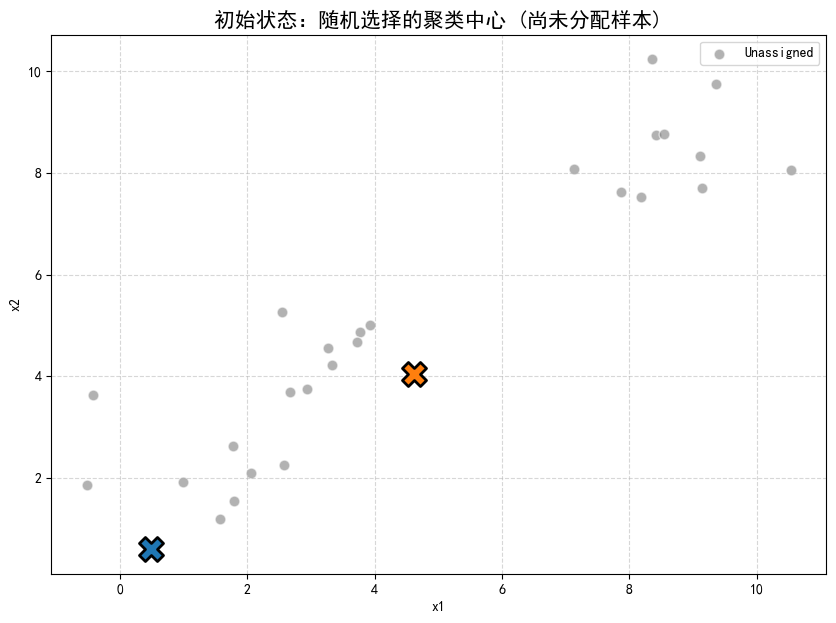

In [5]:
plot_kmeans_step(data, history[0], '初始状态：随机选择的聚类中心 (尚未分配样本)')

### 阶段 2：第一次迭代完成 (Iteration 1)
经过计算所有点到初始中心的距离，样本被染上了距离最近中心的颜色。随后，根据这些新划分的类簇，中心点“X”移动到了类簇的物理重心位置。

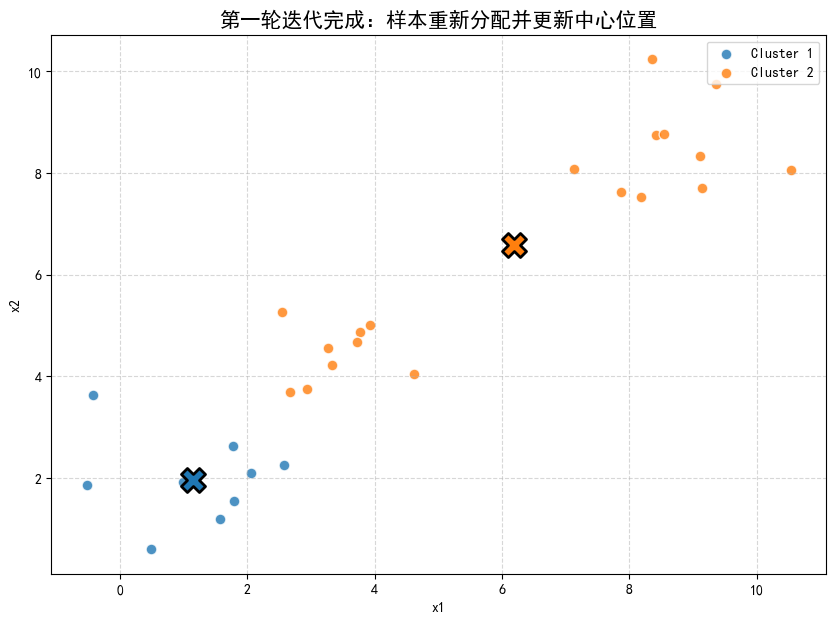

In [6]:
plot_kmeans_step(data, history[1], '第一轮迭代完成：样本重新分配并更新中心位置')

### 阶段 3：最终收敛状态
随着迭代继续，少数处于边界的样本可能会改变所属阵营，中心点也会随之微调。当所有样本的归属不再发生变化时，算法收敛。

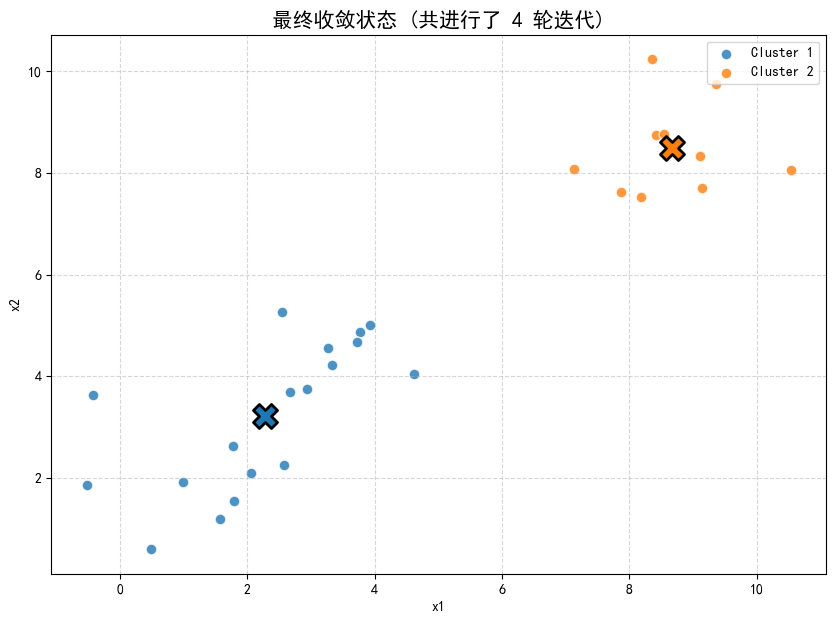

In [7]:
final_state = history[-1]
total_iters = len(history) - 1
plot_kmeans_step(data, final_state, f'最终收敛状态 (共进行了 {total_iters} 轮迭代)')

**过程总结分析：**
由于右上角的数据簇距离左下侧的数据群较远，当 `k=2` 时，K-Means 算法在极少次数的迭代内（通常 2-3 次）就能迅速稳定。左下和中部的数据被强行划分到了一个大类（蓝色 Cluster 1），而右上角密集且游离的数据单独构成了一个类（橙色 Cluster 2）。这体现了基于欧式距离的 K-Means 算法对空间距离的高度敏感性。